# **Personal Loan Acceptance Prediction**

**Objective:** Predict which customers are likely to accept a personal loan offer.

**Dataset:** Bank Marketing Dataset (UCI Machine Learning Repository)  

**Skills Covered:**  
- Data exploration and visualization  
- Classification modeling (Logistic Regression / Decision Tree)  
- Business insight extraction from customer features

## **1- Import Libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings("ignore")

## **2- Load Dataset**

In [3]:
df = pd.read_csv("bank_marketing.csv")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


## **3- Data Exploration**
Check dataset structure, summary statistics, and target distribution.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


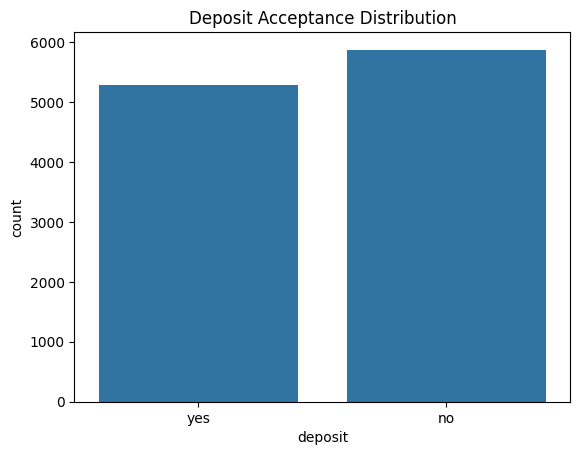

In [4]:
# Dataset info
df.info()

# Summary statistics
df.describe()

# Target distribution
sns.countplot(x='deposit', data=df)
plt.title("Deposit Acceptance Distribution")
plt.show()

## **4- Visualize Key Features**

Explore how `age`, `job`, and `marital` relate to deposit acceptance.

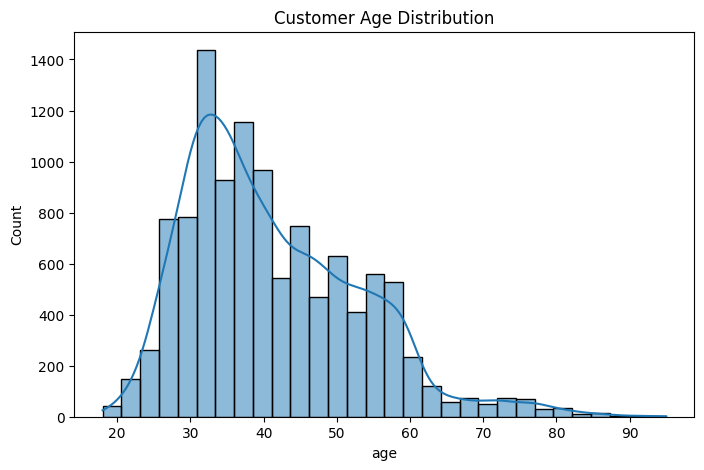

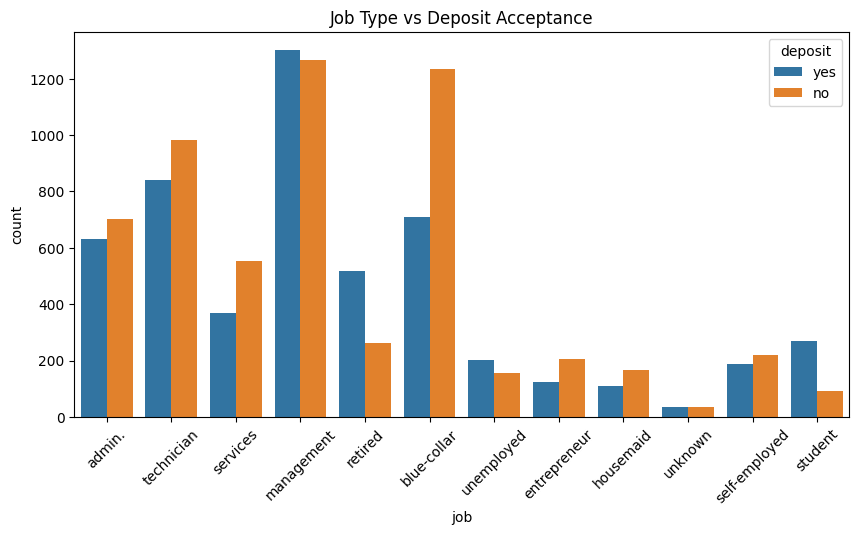

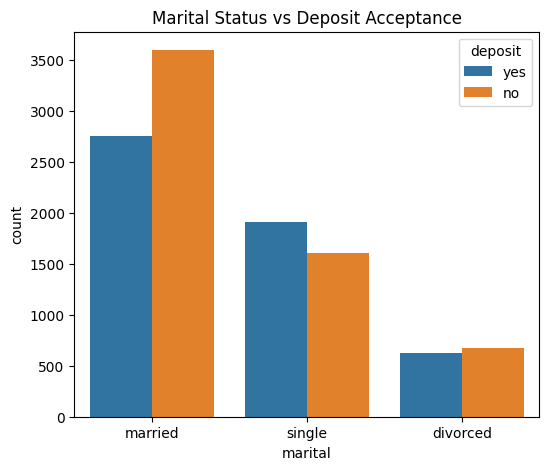

In [5]:
# Age distribution
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=30, kde=True)
plt.title("Customer Age Distribution")
plt.show()

# Job vs Deposit acceptance
plt.figure(figsize=(10,5))
sns.countplot(x='job', hue='deposit', data=df)
plt.title("Job Type vs Deposit Acceptance")
plt.xticks(rotation=45)
plt.show()

# Marital status vs Deposit acceptance
plt.figure(figsize=(6,5))
sns.countplot(x='marital', hue='deposit', data=df)
plt.title("Marital Status vs Deposit Acceptance")
plt.show()

## **5- Data Preprocessing**

- Encode categorical features
- Prepare features (`X`) and target (`y`)

In [6]:
# Encode categorical variables
categorical_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Encode target variable
df_encoded['deposit'] = df_encoded['deposit'].map({'yes':1, 'no':0})

# Features and target
X = df_encoded.drop('deposit', axis=1)
y = df_encoded['deposit']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## **6- Train Classification Model**
I can use **Logistic Regression** or **Decision Tree**.

In [7]:
# Logistic Regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

## **7- Evaluate Model**

Accuracy: 0.813


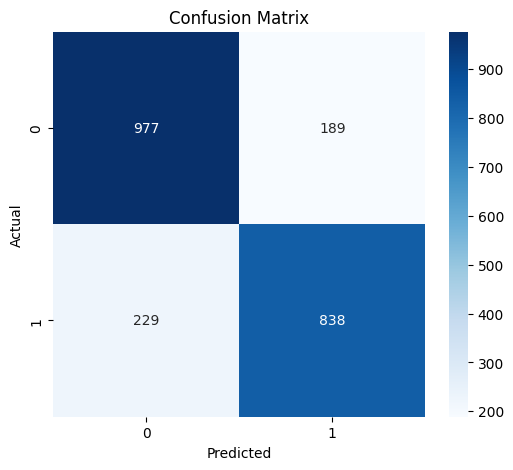

              precision    recall  f1-score   support

           0       0.81      0.84      0.82      1166
           1       0.82      0.79      0.80      1067

    accuracy                           0.81      2233
   macro avg       0.81      0.81      0.81      2233
weighted avg       0.81      0.81      0.81      2233



In [8]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy,3))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print(classification_report(y_test, y_pred))

## **8- Conclusion**

`The model achieves an accuracy of 81%, meaning it correctly predicts whether a customer will accept a personal loan or deposit in 81 out of 100 cases.`

`For non-accepting customers (0), precision is 0.81 and recall is 0.84 — the model correctly identifies most non-acceptors.`

`For accepting customers (1), precision is 0.82 and recall is 0.79 — the model captures most acceptors with slightly lower recall.`

`F1-score: Balanced at ~0.81 for both classes, indicating a good balance between precision and recall.`

**Business Insight**

`The model is reliable for targeting marketing campaigns, helping banks focus on likely acceptors while minimizing outreach to unlikely candidates.`